# 02 — Entrenamiento y evaluación de modelos — EnergiAI (Bloque C)

Entrena, compara y serializa el modelo que clasifica un consumo como *Eficiente*,
*Moderado* o *Ineficiente*, a partir del dataset del Bloque A y los criterios del Bloque B.

**Métrica principal: F1 macro** — pondera las tres clases por igual, protegiendo a las
minoritarias (a diferencia del accuracy, que un modelo trivial podría inflar).

**Estructura:** 1) Carga y split · 2) Baseline (Regresión Logística) · 3) Candidatos
(Árbol y Random Forest + GridSearch) · 4) Comparación y elección · 5) Feature importance ·
6) Serialización · 7) Prueba del ejemplo del brief.

Contrato del modelo: se serializa el **pipeline completo** (preprocesamiento + modelo),
para que el Servicio ML (Bloque D) le pase datos crudos con los mismos nombres de columna.

## 1. Carga y split estratificado

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

RANDOM_STATE = 42

# Columnas segun el Contrato 3 (los nombres son parte del contrato con el Bloque D)
FEATURES_CAT = ["tipo_inmueble"]
FEATURES_NUM = ["consumo_kwh", "cantidad_equipos", "horas_alto_consumo"]
FEATURES_BOOL = ["uso_horario_pico"]
FEATURES = FEATURES_CAT + FEATURES_NUM + FEATURES_BOOL
TARGET = "categoria"

CANDIDATOS = [Path("../data/dataset_energia.csv"), Path("data-science/data/dataset_energia.csv")]
RUTA_CSV = next(p for p in CANDIDATOS if p.exists())
df = pd.read_csv(RUTA_CSV)
X = df[FEATURES]
y = df[TARGET]
print(f"Dataset: {len(df)} filas | features: {FEATURES} | target: {TARGET}")
df.head()

Dataset: 4000 filas | features: ['tipo_inmueble', 'consumo_kwh', 'cantidad_equipos', 'horas_alto_consumo', 'uso_horario_pico'] | target: categoria


,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,categoria
0,202.54,False,2,Departamento,12,Ineficiente
1,225.13,True,6,Casa,7,Eficiente
2,920.43,True,13,Local,10,Ineficiente
3,218.95,False,5,Departamento,7,Moderado
4,170.40,False,8,Casa,6,Eficiente


In [2]:
# Split estratificado: conserva la proporcion de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"train: {len(X_train)}  |  test: {len(X_test)}")
print("\nProporcion de clases (train):")
print((y_train.value_counts(normalize=True) * 100).round(1).to_string())
print("\nProporcion de clases (test):")
print((y_test.value_counts(normalize=True) * 100).round(1).to_string())

train: 3200  |  test: 800

Proporcion de clases (train):
categoria
Ineficiente    35.0
Eficiente      32.8
Moderado       32.2

Proporcion de clases (test):
categoria
Ineficiente    35.0
Eficiente      32.9
Moderado       32.1


In [3]:
# Preprocesamiento compartido por todos los modelos: OneHot al tipo, escalado a las numericas.
# uso_horario_pico pasa tal cual (0/1) por remainder='passthrough'.
def build_preproc():
    return ColumnTransformer(
        [
            ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
            ("num", StandardScaler(), FEATURES_NUM),
        ],
        remainder="passthrough",
    )


# Guardaremos aqui las metricas de cada modelo para la tabla comparativa final (seccion 4).
resultados = {}


def evaluar(nombre, pipe):
    """Entrena, evalua en test y con CV 5-fold, y registra las metricas."""
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    cv = cross_val_score(pipe, X, y, cv=5, scoring="f1_macro")
    resultados[nombre] = {"accuracy": acc, "f1_macro": f1,
                          "cv_f1_mean": cv.mean(), "cv_f1_std": cv.std()}
    print(f"{nombre}\n  accuracy = {acc:.3f}\n  f1_macro = {f1:.3f}"
          f"\n  cv f1_macro = {cv.mean():.3f} +/- {cv.std():.3f}\n")
    print(classification_report(y_test, pred))
    return pipe, pred

## 2. Baseline — Regresión Logística

Siempre se empieza por un modelo simple e interpretable: da un piso de referencia contra
el cual justificar (o no) modelos más complejos.

In [4]:
pipe_logreg = Pipeline([
    ("preproc", build_preproc()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
pipe_logreg, pred_logreg = evaluar("LogisticRegression", pipe_logreg)

LogisticRegression
  accuracy = 0.932
  f1_macro = 0.932
  cv f1_macro = 0.938 +/- 0.006

              precision    recall  f1-score   support

   Eficiente       0.95      0.97      0.96       263
 Ineficiente       0.94      0.95      0.94       280
    Moderado       0.90      0.88      0.89       257

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



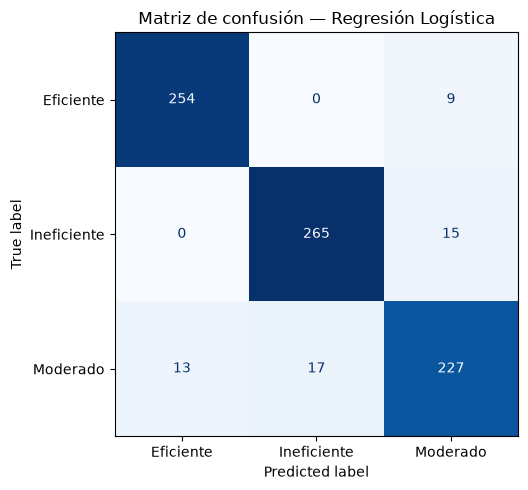

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, colorbar=False,
                                        cmap="Blues")
ax.set_title("Matriz de confusión — Regresión Logística")
plt.tight_layout()
plt.show()

El baseline ya alcanza un **F1 macro ~0.93**: el problema es bastante separable (esperable,
porque las etiquetas vienen de una fórmula por reglas del Bloque B). La confusión que queda
se concentra en la frontera *Moderado* ↔ vecinas, justo donde el índice está cerca de un umbral.
En las siguientes secciones vemos si un modelo no lineal mejora esto lo suficiente como para
justificar perder interpretabilidad.

## 3. Candidatos — Árbol de Decisión y Random Forest

Probamos dos modelos no lineales recomendados por el brief. El Árbol es muy interpretable; el Random Forest suele dar mejor rendimiento a cambio de algo de interpretabilidad.

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

### 3.1 Árbol de Decisión

In [7]:
pipe_arbol = Pipeline([
    ("preproc", build_preproc()),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])
pipe_arbol, pred_arbol = evaluar("DecisionTree", pipe_arbol)

DecisionTree
  accuracy = 0.915
  f1_macro = 0.914
  cv f1_macro = 0.907 +/- 0.010

              precision    recall  f1-score   support

   Eficiente       0.95      0.95      0.95       263
 Ineficiente       0.92      0.92      0.92       280
    Moderado       0.87      0.87      0.87       257

    accuracy                           0.92       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.92      0.91       800



### 3.2 Random Forest (por defecto)

In [8]:
pipe_rf = Pipeline([
    ("preproc", build_preproc()),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE)),
])
pipe_rf, pred_rf = evaluar("RandomForest", pipe_rf)

RandomForest
  accuracy = 0.961
  f1_macro = 0.961
  cv f1_macro = 0.943 +/- 0.010

              precision    recall  f1-score   support

   Eficiente       0.97      0.98      0.97       263
 Ineficiente       0.97      0.97      0.97       280
    Moderado       0.95      0.93      0.94       257

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800



### 3.3 Random Forest con GridSearchCV

Búsqueda ligera de hiperparámetros optimizando **F1 macro** con validación cruzada 5-fold.

In [9]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
}
grid = GridSearchCV(
    Pipeline([("preproc", build_preproc()),
              ("model", RandomForestClassifier(random_state=RANDOM_STATE))]),
    param_grid, cv=5, scoring="f1_macro", n_jobs=-1,
)
grid.fit(X_train, y_train)
print("Mejores parametros:", grid.best_params_)
print(f"Mejor F1 macro (CV): {grid.best_score_:.3f}")

Mejores parametros: {'model__max_depth': None, 'model__n_estimators': 100}
Mejor F1 macro (CV): 0.938


In [10]:
# Evaluamos el mejor RF en el test y lo registramos para la tabla comparativa
best_rf = grid.best_estimator_
pred_best = best_rf.predict(X_test)
acc = accuracy_score(y_test, pred_best)
f1 = f1_score(y_test, pred_best, average="macro")
cv = cross_val_score(best_rf, X, y, cv=5, scoring="f1_macro")
resultados["RandomForest (tuned)"] = {"accuracy": acc, "f1_macro": f1,
                                       "cv_f1_mean": cv.mean(), "cv_f1_std": cv.std()}
print(f"RandomForest (tuned)\n  accuracy = {acc:.3f}\n  f1_macro = {f1:.3f}"
      f"\n  cv f1_macro = {cv.mean():.3f} +/- {cv.std():.3f}\n")
print(classification_report(y_test, pred_best))

RandomForest (tuned)
  accuracy = 0.961
  f1_macro = 0.961
  cv f1_macro = 0.943 +/- 0.010

              precision    recall  f1-score   support

   Eficiente       0.97      0.98      0.97       263
 Ineficiente       0.97      0.97      0.97       280
    Moderado       0.95      0.93      0.94       257

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800



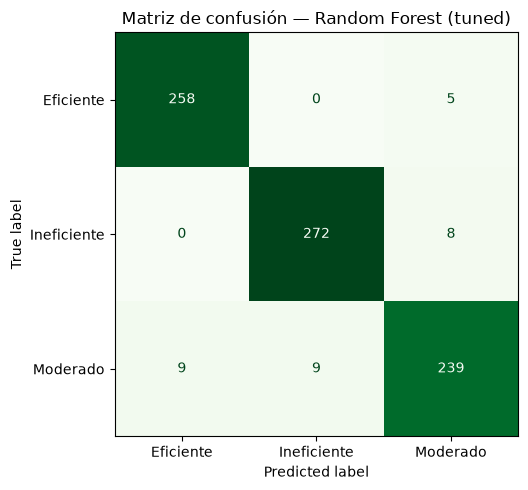

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_best, ax=ax, colorbar=False,
                                        cmap="Greens")
ax.set_title("Matriz de confusión — Random Forest (tuned)")
plt.tight_layout()
plt.show()

**Lo que vemos:** el Árbol de Decisión queda por debajo del baseline lineal, mientras que el **Random Forest mejora claramente** (F1 macro ~0.96). El GridSearch confirma que los hiperparámetros por defecto ya son prácticamente óptimos. La confusión residual sigue estando en la clase *Moderado* (la del medio), lo cual es esperable. En la sección 4 consolidamos la comparación y elegimos el modelo final.

## 4. Comparación y elección del modelo

In [12]:
tabla = (pd.DataFrame(resultados).T
         .sort_values("f1_macro", ascending=False)
         .round(3))
tabla

,accuracy,f1_macro,cv_f1_mean,cv_f1_std
RandomForest (tuned),0.961,0.961,0.943,0.010
RandomForest,0.961,0.961,0.943,0.010
LogisticRegression,0.932,0.932,0.938,0.006
DecisionTree,0.915,0.914,0.907,0.010


**Modelo elegido: Random Forest (tuned).**

Es el de mayor F1 macro en test (~0.96) y en validación cruzada, superando con claridad al baseline lineal (~0.93) y al Árbol (~0.91). La diferencia frente a la Regresión Logística (~0.03 de F1 macro) es consistente entre test y CV, así que **no es ruido**: justifica elegir el modelo no lineal.

> Criterio de desempate del brief: si RF y LogReg empataran, se elegiría LogReg por interpretabilidad. Aquí no empatan — RF gana de forma estable —, por lo que se elige RF.

## 5. Importancia de las variables (feature importance)

Qué features pesan más en la decisión del modelo. Es **insumo directo para el Bloque H**: indica qué hábitos disparan la ineficiencia y, por tanto, qué recomendar.

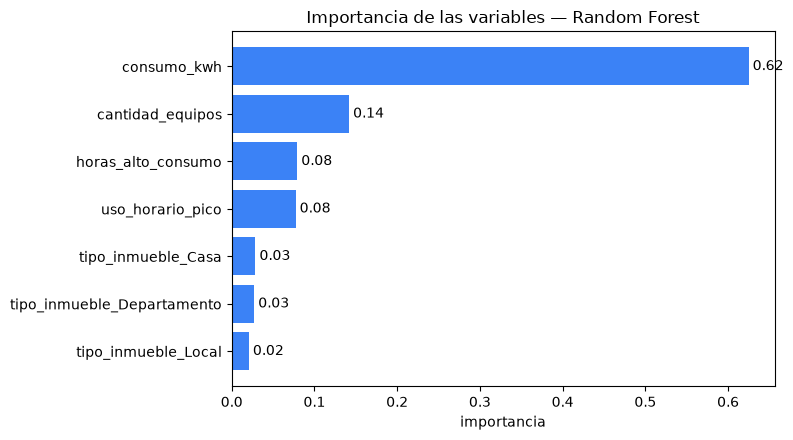

consumo_kwh                   0.624878
cantidad_equipos              0.141873
horas_alto_consumo            0.079263
uso_horario_pico              0.077287
tipo_inmueble_Casa            0.028693
tipo_inmueble_Departamento    0.027240
tipo_inmueble_Local           0.020766
dtype: float64

In [13]:
# Nombres de las features despues del preprocesamiento + importancias del RF
preproc_fit = best_rf.named_steps["preproc"]
nombres = preproc_fit.get_feature_names_out()
# Limpiamos los prefijos del ColumnTransformer para legibilidad
nombres = [n.split("__", 1)[-1] for n in nombres]
importancias = best_rf.named_steps["model"].feature_importances_
fi = (pd.Series(importancias, index=nombres)
      .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(fi.index, fi.values, color="#3b82f6")
ax.set_title("Importancia de las variables — Random Forest")
ax.set_xlabel("importancia")
for i, v in enumerate(fi.values):
    ax.text(v, i, f" {v:.2f}", va="center")
plt.tight_layout()
plt.show()
fi.sort_values(ascending=False)

Como anticipaba el EDA (Bloque B), **`consumo_kwh` domina** la decisión, seguido del consumo por número de equipos y de las horas de alto consumo. El horario pico aporta menos, coherente con su rol de agravante. Para el Bloque H: priorizar recomendaciones sobre reducir consumo y redistribuir las horas de alto uso.

## 6. Serialización del pipeline

Se guarda el **pipeline completo** (preprocesamiento + modelo), nunca el modelo solo: así el Servicio ML (Bloque D) le pasa datos crudos con los nombres del Contrato 3 y el pipeline se encarga de transformarlos. Se guarda además un `metadata.json` con la trazabilidad.

In [14]:
import json
from datetime import datetime, timezone
import sklearn
import joblib

MODELS_DIR = next(p for p in [Path("../models"), Path("data-science/models")] if p.exists())
RUTA_MODELO = MODELS_DIR / "modelo.joblib"
RUTA_META = MODELS_DIR / "metadata.json"

# compress=3 reduce el tamano del .joblib para que quepa comodo en el repo
joblib.dump(best_rf, RUTA_MODELO, compress=3)

res = resultados["RandomForest (tuned)"]
metadata = {
    "modelo": "RandomForestClassifier (pipeline con OneHot + StandardScaler)",
    "fecha_entrenamiento": datetime.now(timezone.utc).isoformat(),
    "sklearn_version": sklearn.__version__,
    "mejores_params": grid.best_params_,
    "metricas_test": {"accuracy": round(res["accuracy"], 4),
                       "f1_macro": round(res["f1_macro"], 4)},
    "cv_f1_macro": {"mean": round(res["cv_f1_mean"], 4),
                     "std": round(res["cv_f1_std"], 4)},
    "features": FEATURES,
    "clases": list(best_rf.named_steps["model"].classes_),
    "n_registros_dataset": len(df),
}
RUTA_META.write_text(json.dumps(metadata, indent=2, ensure_ascii=False))

tam_mb = RUTA_MODELO.stat().st_size / 1e6
print(f"Modelo guardado: {RUTA_MODELO} ({tam_mb:.2f} MB)")
print(f"Metadata guardada: {RUTA_META}")
print(json.dumps(metadata, indent=2, ensure_ascii=False))

Modelo guardado: ../models/modelo.joblib (1.32 MB)
Metadata guardada: ../models/metadata.json
{
  "modelo": "RandomForestClassifier (pipeline con OneHot + StandardScaler)",
  "fecha_entrenamiento": "2026-07-21T00:35:39.071780+00:00",
  "sklearn_version": "1.9.0",
  "mejores_params": {
    "model__max_depth": null,
    "model__n_estimators": 100
  },
  "metricas_test": {
    "accuracy": 0.9613,
    "f1_macro": 0.9608
  },
  "cv_f1_macro": {
    "mean": 0.9432,
    "std": 0.0096
  },
  "features": [
    "tipo_inmueble",
    "consumo_kwh",
    "cantidad_equipos",
    "horas_alto_consumo",
    "uso_horario_pico"
  ],
  "clases": [
    "Eficiente",
    "Ineficiente",
    "Moderado"
  ],
  "n_registros_dataset": 4000
}


## 7. Prueba de sanidad — ejemplo del brief y perfiles contrastantes

Cargamos el modelo serializado (como lo hará el Bloque D) y verificamos que el ejemplo canónico del brief da **Ineficiente**, y que perfiles distintos producen clases distintas.

In [15]:
modelo_cargado = joblib.load(RUTA_MODELO)

ejemplos = pd.DataFrame([
    # Ejemplo canonico del brief -> debe ser Ineficiente
    {"tipo_inmueble": "Casa", "consumo_kwh": 420, "cantidad_equipos": 10,
     "horas_alto_consumo": 8, "uso_horario_pico": True},
    # Perfil claramente eficiente
    {"tipo_inmueble": "Departamento", "consumo_kwh": 120, "cantidad_equipos": 5,
     "horas_alto_consumo": 2, "uso_horario_pico": False},
    # Perfil intermedio
    {"tipo_inmueble": "Casa", "consumo_kwh": 330, "cantidad_equipos": 9,
     "horas_alto_consumo": 6, "uso_horario_pico": False},
])[FEATURES]

pred = modelo_cargado.predict(ejemplos)
proba = modelo_cargado.predict_proba(ejemplos).max(axis=1).round(2)
salida = ejemplos.copy()
salida["prediccion"] = pred
salida["probabilidad"] = proba
print(salida.to_string(index=False))

assert pred[0] == "Ineficiente", "El ejemplo del brief deberia ser Ineficiente"
print("\nOK: el ejemplo del brief se clasifica como Ineficiente"
      f" con probabilidad {proba[0]:.2f}")

tipo_inmueble  consumo_kwh  cantidad_equipos  horas_alto_consumo  uso_horario_pico  prediccion  probabilidad
         Casa          420                10                   8              True Ineficiente          0.97
 Departamento          120                 5                   2             False   Eficiente          1.00
         Casa          330                 9                   6             False   Eficiente          0.83

OK: el ejemplo del brief se clasifica como Ineficiente con probabilidad 0.97


**Resultado:** el ejemplo del brief se clasifica como **Ineficiente** con alta probabilidad, y los tres perfiles producen clases distintas y coherentes. El modelo (`models/modelo.joblib`) queda listo para que el Bloque D lo cargue y exponga vía `POST /predict`.

**Cierre del Bloque C:** pipeline serializado + `metadata.json`, F1 macro ~0.96, comparación documentada. Siguiente paso: subirlo a OCI Object Storage (`upload_model.py`) y avisar al Bloque D.